<a href="https://colab.research.google.com/github/it0770e/xai-ids/blob/main/Notebook02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CELL 1
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, os, warnings
warnings.filterwarnings('ignore')
BASE = '/content/drive/MyDrive/xai-ids'
print('✅ Setup complete')

Mounted at /content/drive
✅ Setup complete


In [2]:
# CELL 2
print('📥 Downloading NSL-KDD...')
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations','num_shells',
    'num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count',
    'srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
    'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate',
    'label','difficulty'
]
df_train = pd.read_csv('https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt', names=columns)
df_test  = pd.read_csv('https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt',  names=columns)
print(f'✅ Train: {df_train.shape}  |  Test: {df_test.shape}')

📥 Downloading NSL-KDD...
✅ Train: (125973, 43)  |  Test: (22544, 43)


In [3]:
# CELL 3
attack_categories = {
    'back':'DoS','land':'DoS','neptune':'DoS','pod':'DoS','smurf':'DoS','teardrop':'DoS',
    'mailbomb':'DoS','apache2':'DoS','processtable':'DoS','udpstorm':'DoS',
    'ipsweep':'Probe','nmap':'Probe','portsweep':'Probe','satan':'Probe','mscan':'Probe','saint':'Probe',
    'buffer_overflow':'R2L','guess_passwd':'R2L','imap':'R2L','multihop':'R2L','phf':'R2L',
    'spy':'R2L','warezclient':'R2L','warezmaster':'R2L','sendmail':'R2L','named':'R2L',
    'snmpgetattack':'R2L','snmpguess':'R2L','xlock':'R2L','xsnoop':'R2L','worm':'R2L','httptunnel':'R2L',
    'rootkit':'U2R','perl':'U2R','sqlattack':'U2R','xterm':'U2R','ps':'U2R'
}
for df in [df_train, df_test]:
    df['binary_label']    = (df['label'] != 'normal').astype(int)
    df['attack_category'] = df['label'].map(attack_categories).fillna('BENIGN')

print('📊 Training class distribution:')
for lbl, cnt in df_train['binary_label'].value_counts().items():
    print(f'   {"Normal" if lbl==0 else "Attack"}: {cnt:,} ({cnt/len(df_train):.1%})')
print('\n📊 Attack categories:')
print(df_train['attack_category'].value_counts())

📊 Training class distribution:
   Normal: 67,343 (53.5%)
   Attack: 58,630 (46.5%)

📊 Attack categories:
attack_category
BENIGN    67360
DoS       45927
Probe     11656
R2L        1017
U2R          13
Name: count, dtype: int64


In [4]:
# CELL 4 — Data quality
print(f'Missing values (train): {df_train.isnull().sum().sum()}')
print(f'Missing values (test) : {df_test.isnull().sum().sum()}')
print(f'Duplicate rows (train): {df_train.duplicated().sum()}')
cat_cols = df_train.select_dtypes(include='object').columns.tolist()
print(f'Categorical features: {[c for c in cat_cols if c not in ["label","attack_category"]]}')
print('\nKey feature stats:')
print(df_train[['duration','src_bytes','dst_bytes','count','serror_rate']].describe().round(3))

Missing values (train): 0
Missing values (test) : 0
Duplicate rows (train): 0
Categorical features: ['protocol_type', 'service', 'flag']

Key feature stats:
         duration     src_bytes     dst_bytes       count  serror_rate
count  125973.000  1.259730e+05  1.259730e+05  125973.000   125973.000
mean      287.145  4.556674e+04  1.977911e+04      84.108        0.284
std      2604.515  5.870331e+06  4.021269e+06     114.509        0.446
min         0.000  0.000000e+00  0.000000e+00       0.000        0.000
25%         0.000  0.000000e+00  0.000000e+00       2.000        0.000
50%         0.000  4.400000e+01  0.000000e+00      14.000        0.000
75%         0.000  2.760000e+02  5.160000e+02     143.000        1.000
max     42908.000  1.379964e+09  1.309937e+09     511.000        1.000


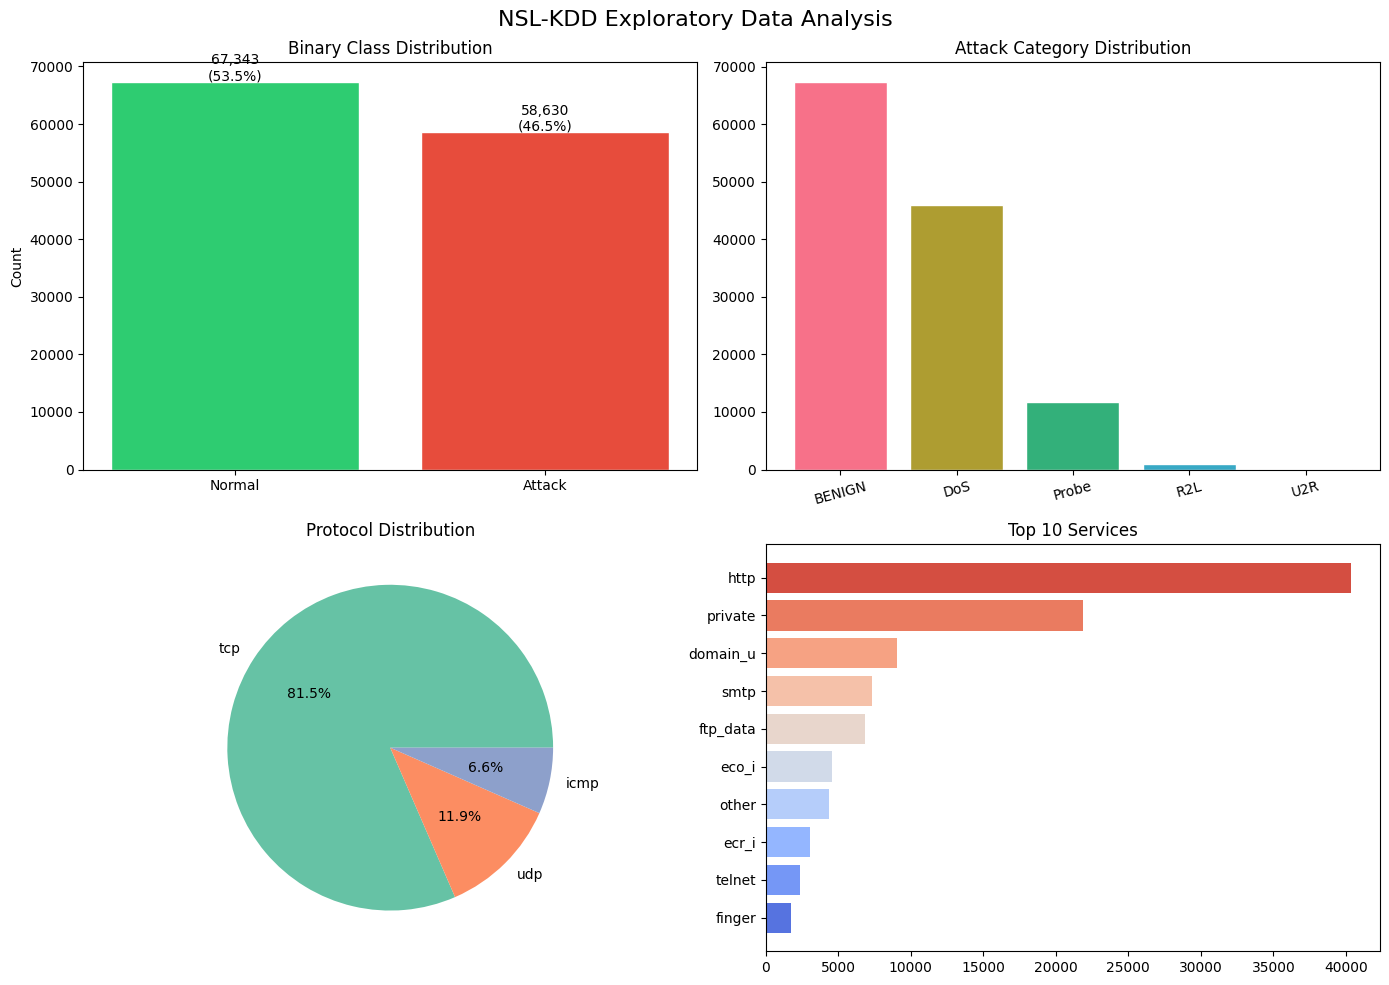

✅ EDA figure saved


In [5]:
# CELL 5 — EDA plots
fig, axes = plt.subplots(2, 2, figsize=(14,10))
plt.suptitle('NSL-KDD Exploratory Data Analysis', fontsize=16)

cc = df_train['binary_label'].value_counts()
axes[0,0].bar(['Normal','Attack'], cc.values, color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[0,0].set_title('Binary Class Distribution')
axes[0,0].set_ylabel('Count')
for i,v in enumerate(cc.values):
    axes[0,0].text(i, v+200, f'{v:,}\n({v/len(df_train):.1%})', ha='center', fontsize=10)

cat_c = df_train['attack_category'].value_counts()
axes[0,1].bar(cat_c.index, cat_c.values, color=sns.color_palette('husl',len(cat_c)), edgecolor='white')
axes[0,1].set_title('Attack Category Distribution')
axes[0,1].tick_params(axis='x', rotation=15)

proto = df_train['protocol_type'].value_counts()
axes[1,0].pie(proto.values, labels=proto.index, autopct='%1.1f%%', colors=sns.color_palette('Set2',3))
axes[1,0].set_title('Protocol Distribution')

top_svc = df_train['service'].value_counts().head(10)
axes[1,1].barh(range(10), top_svc.values[::-1], color=sns.color_palette('coolwarm',10))
axes[1,1].set_yticks(range(10))
axes[1,1].set_yticklabels(top_svc.index[::-1])
axes[1,1].set_title('Top 10 Services')

plt.tight_layout()
plt.savefig(f'{BASE}/results/figures/nsl_kdd_eda.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ EDA figure saved')